# Bitcoin-OTC Trust Network: Polarization and Distrust Over Time

**Research Question:**  
> *Has the Bitcoin-OTC network become more polarized and distrustful over time? Are there periods of rupture characterized by abrupt spikes in negative ratings, suggesting collective shifts in the network's trust behavior?*

## Methodology Overview

We address this question through four complementary lenses:

1. Temporal evolution of negative ratings — monthly and yearly volumes of distrust signals  
2. Structural polarization metrics — negative-to-total ratio, average rating trend, anomaly (rupture) detection  
3. Network topology over time — how the trust/distrust subgraph properties evolve  
4. User-level behavior — cohort analysis and newcomers vs. established users


## 1. Setup and Data Loading

In [21]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

# Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
TRUST_COLOR   = '#2ecc71'   # green  → positive ratings
DISTRUST_COLOR = '#e74c3c'  # red    → negative ratings
NEUTRAL_COLOR  = '#3498db'  # blue   → all ratings
RUPTURE_COLOR  = '#e67e22'  # orange → detected rupture periods

In [18]:
# Load
DATA_PATH = '/content/drive/MyDrive/MO412_Project_v2/soc-sign-bitcoinotc.csv'

df = pd.read_csv(DATA_PATH)
df.columns = ['source', 'target', 'rating', 'time']

# Parse timestamps
df['timestamp'] = pd.to_datetime(df['time'], unit='s')
df['year']      = df['timestamp'].dt.year
df['month']     = df['timestamp'].dt.to_period('M')
df['quarter']   = df['timestamp'].dt.to_period('Q')

# Categorise ratings
df['is_negative'] = df['rating'] < 0
df['is_positive'] = df['rating'] > 0
df['is_neutral']  = df['rating'] == 0

print(f"Dataset: {len(df):,} edges  |  {df['source'].nunique():,} unique sources  |  {df['target'].nunique():,} unique targets")
print(f"Period : {df['timestamp'].min().date()}  →  {df['timestamp'].max().date()}")
print(f"Ratings: min={df['rating'].min()}  max={df['rating'].max()}  mean={df['rating'].mean():.3f}")
print(f"Negative edges : {df['is_negative'].sum():,}  ({100*df['is_negative'].mean():.1f}%)")
print(f"Positive edges : {df['is_positive'].sum():,}  ({100*df['is_positive'].mean():.1f}%)")
print(f"Neutral edges : {df['is_neutral'].sum():,}  ({100*df['is_neutral'].mean():.1f}%)")

Dataset: 35,592 edges  |  4,814 unique sources  |  5,858 unique targets
Period : 2010-11-08  →  2016-01-25
Ratings: min=-10  max=10  mean=1.012
Negative edges : 3,563  (10.0%)
Positive edges : 32,029  (90.0%)
Neutral edges : 0  (0.0%)


## 2. Temporal Evolution of Negative Ratings

We first examine how the volume and proportion of negative ratings changed month by month. An upward trend in the negative-rating share is a direct signal of growing distrust in the network.

In [31]:
# Monthly aggregation
monthly = (
    df.groupby('month')
    .agg(
        total    = ('rating', 'count'),
        negative = ('is_negative', 'sum'),
        positive = ('is_positive', 'sum'),
        avg_rating = ('rating', 'mean'),
    )
    .reset_index()
)
monthly['neg_ratio']  = monthly['negative'] / monthly['total']
monthly['month_ts']   = monthly['month'].dt.to_timestamp()

# Rolling 3-month average for smoothing
monthly['neg_ratio_3m'] = monthly['neg_ratio'].rolling(3, center=True).mean()
monthly['avg_rating_3m'] = monthly['avg_rating'].rolling(3, center=True).mean()

monthly.head()

,month,total,negative,positive,avg_rating,neg_ratio,month_ts,neg_ratio_3m,avg_rating_3m
0,2010-11,60,0,60,3.633333,0.000000,2010-11-01,NaN,NaN
1,2010-12,82,0,82,2.109756,0.000000,2010-12-01,0.000000,2.453084
2,2011-01,99,0,99,1.616162,0.000000,2011-01-01,0.000000,1.820204
3,2011-02,245,0,245,1.734694,0.000000,2011-02-01,0.008591,1.654753
4,2011-03,194,5,189,1.613402,0.025773,2011-03-01,0.009187,1.789854


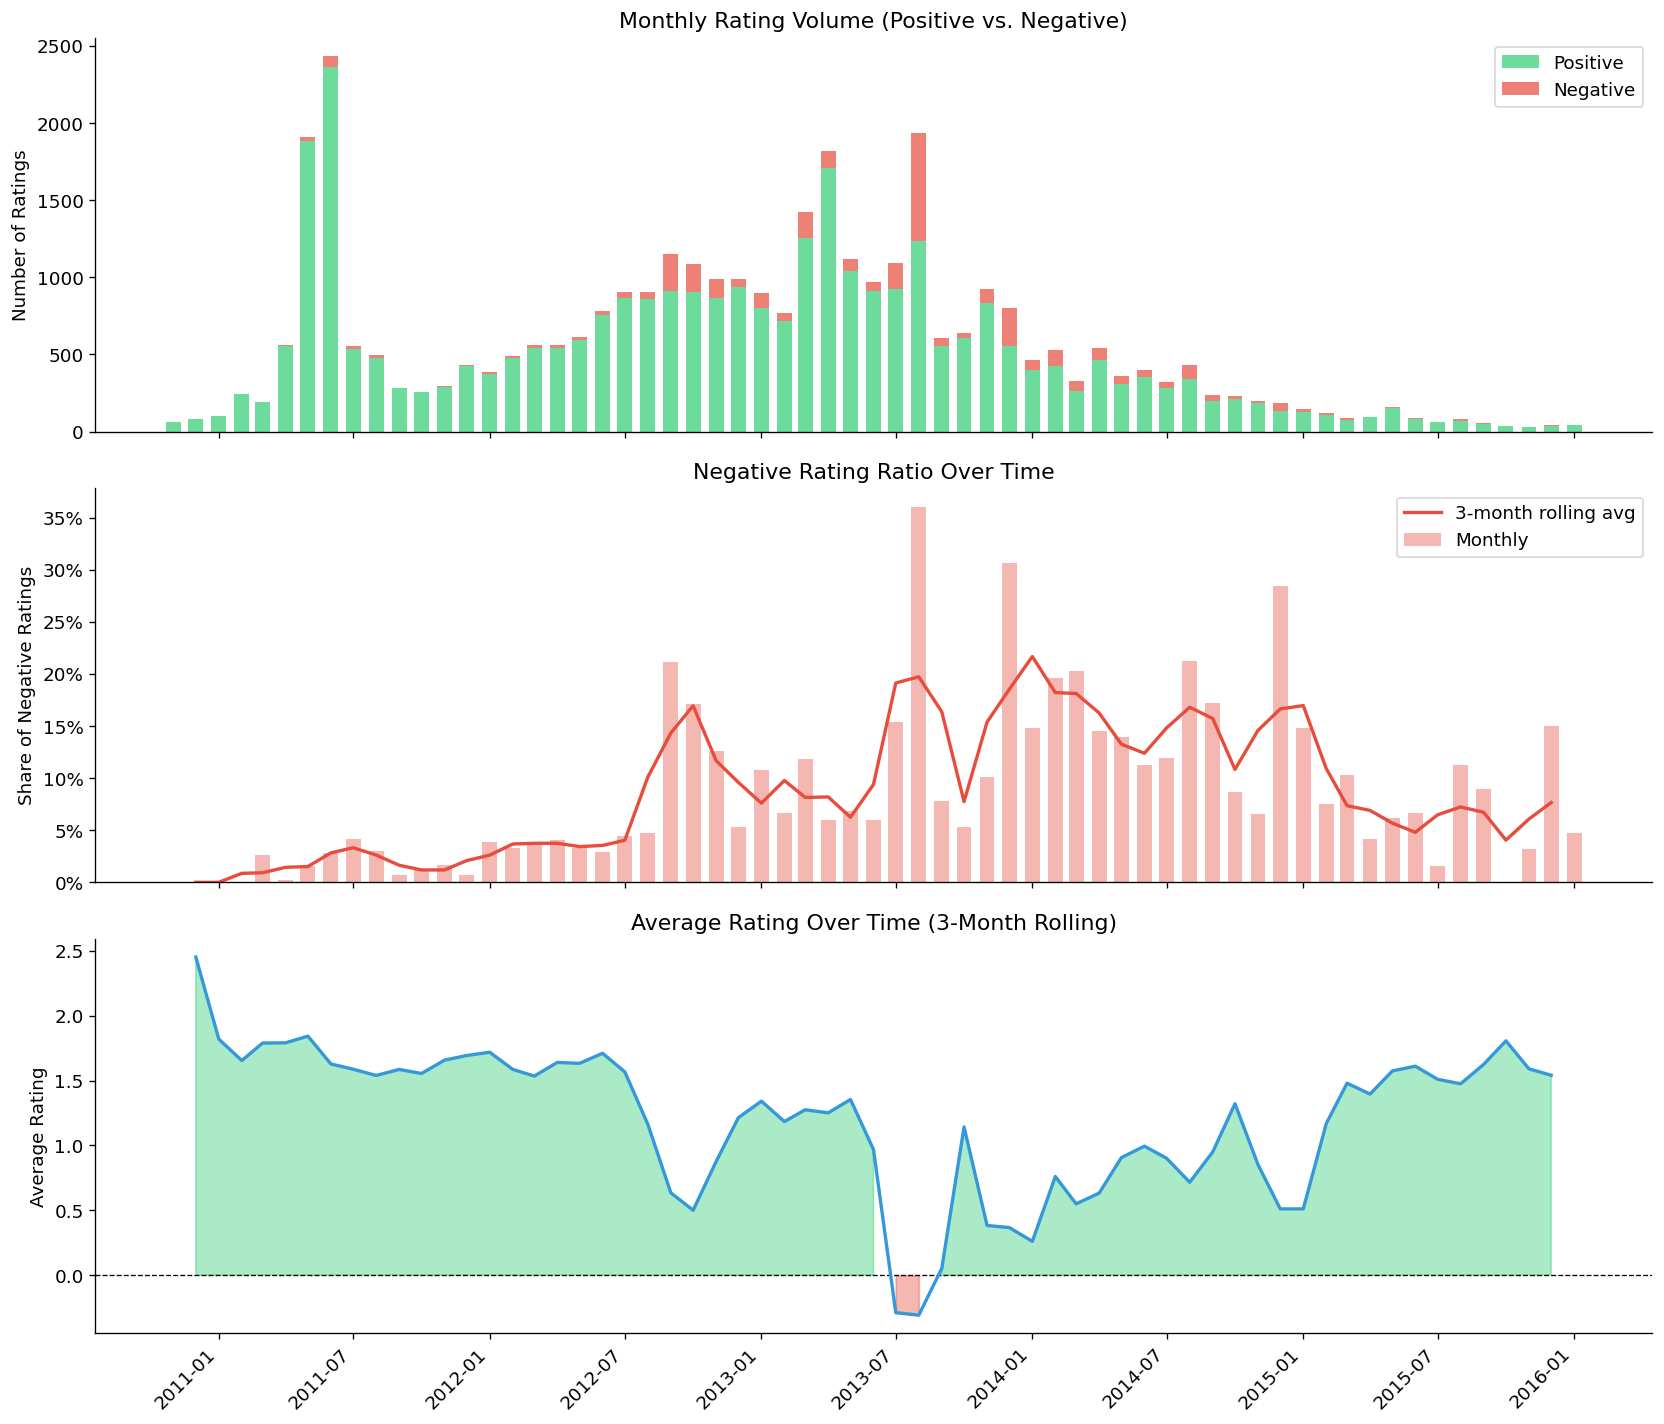

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Monthly edge volume
ax = axes[0]
ax.bar(monthly['month_ts'], monthly['positive'],  color=TRUST_COLOR,    alpha=0.7, label='Positive', width=20)
ax.bar(monthly['month_ts'], monthly['negative'],  color=DISTRUST_COLOR, alpha=0.7, label='Negative',
       bottom=monthly['positive'], width=20)
ax.set_ylabel('Number of Ratings')
ax.set_title('Monthly Rating Volume (Positive vs. Negative)')
ax.legend()

# Panel 2: Negative ratio over time
ax = axes[1]
ax.bar(monthly['month_ts'], monthly['neg_ratio'], color=DISTRUST_COLOR, alpha=0.4, width=20, label='Monthly')
ax.plot(monthly['month_ts'], monthly['neg_ratio_3m'], color=DISTRUST_COLOR, linewidth=2, label='3-month rolling avg')
ax.set_ylabel('Share of Negative Ratings')
ax.set_title('Negative Rating Ratio Over Time')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()

# Panel 3: Average rating over time
ax = axes[2]
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(monthly['month_ts'], monthly['avg_rating_3m'], 0,
                where=monthly['avg_rating_3m'] >= 0, color=TRUST_COLOR, alpha=0.4)
ax.fill_between(monthly['month_ts'], monthly['avg_rating_3m'], 0,
                where=monthly['avg_rating_3m'] < 0,  color=DISTRUST_COLOR, alpha=0.4)
ax.plot(monthly['month_ts'], monthly['avg_rating_3m'], color=NEUTRAL_COLOR, linewidth=2)
ax.set_ylabel('Average Rating')
ax.set_title('Average Rating Over Time (3-Month Rolling)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rupture Detection — Abrupt Spikes in Distrust

A rupture period is defined as a month where the negative-rating ratio deviates significantly from the recent baseline.  
We use a Z-score approach on a rolling window: any month with Z-score > 2.0 is flagged as an anomaly (potential collective shift).

In [44]:
# Z-score based rupture detection
WINDOW       = 6    # months for rolling baseline
Z_THRESHOLD  = 2.0  # standard deviations

monthly['roll_mean'] = monthly['neg_ratio'].rolling(WINDOW, min_periods=3).mean().shift(1)
monthly['roll_std']  = monthly['neg_ratio'].rolling(WINDOW, min_periods=3).std().shift(1)
monthly['z_score']   = (monthly['neg_ratio'] - monthly['roll_mean']) / (monthly['roll_std'] + 1e-9)
monthly['is_rupture'] = monthly['z_score'].abs() > Z_THRESHOLD

ruptures = monthly[monthly['is_rupture']]
print(f"Detected {len(ruptures)} rupture months (|Z| > {Z_THRESHOLD}):")
print(ruptures[['month', 'total', 'negative', 'neg_ratio', 'z_score']]
      .rename(columns={'neg_ratio': 'neg_ratio(%)'})
      .assign(**{'neg_ratio(%)': lambda x: (x['neg_ratio(%)'] * 100).round(1)})
      .to_string(index=False))

Detected 7 rupture months (|Z| > 2.0):
  month  total  negative  neg_ratio(%)      z_score
2011-03    194         5           2.6 2.577320e+07
2011-07    558        23           4.1 2.251182e+00
2012-09   1153       244          21.2 2.529455e+01
2013-07   1091       168          15.4 2.819679e+00
2013-08   1934       697          36.0 6.926750e+00
2014-12    186        53          28.5 2.857359e+00
2015-12     40         6          15.0 2.209796e+00


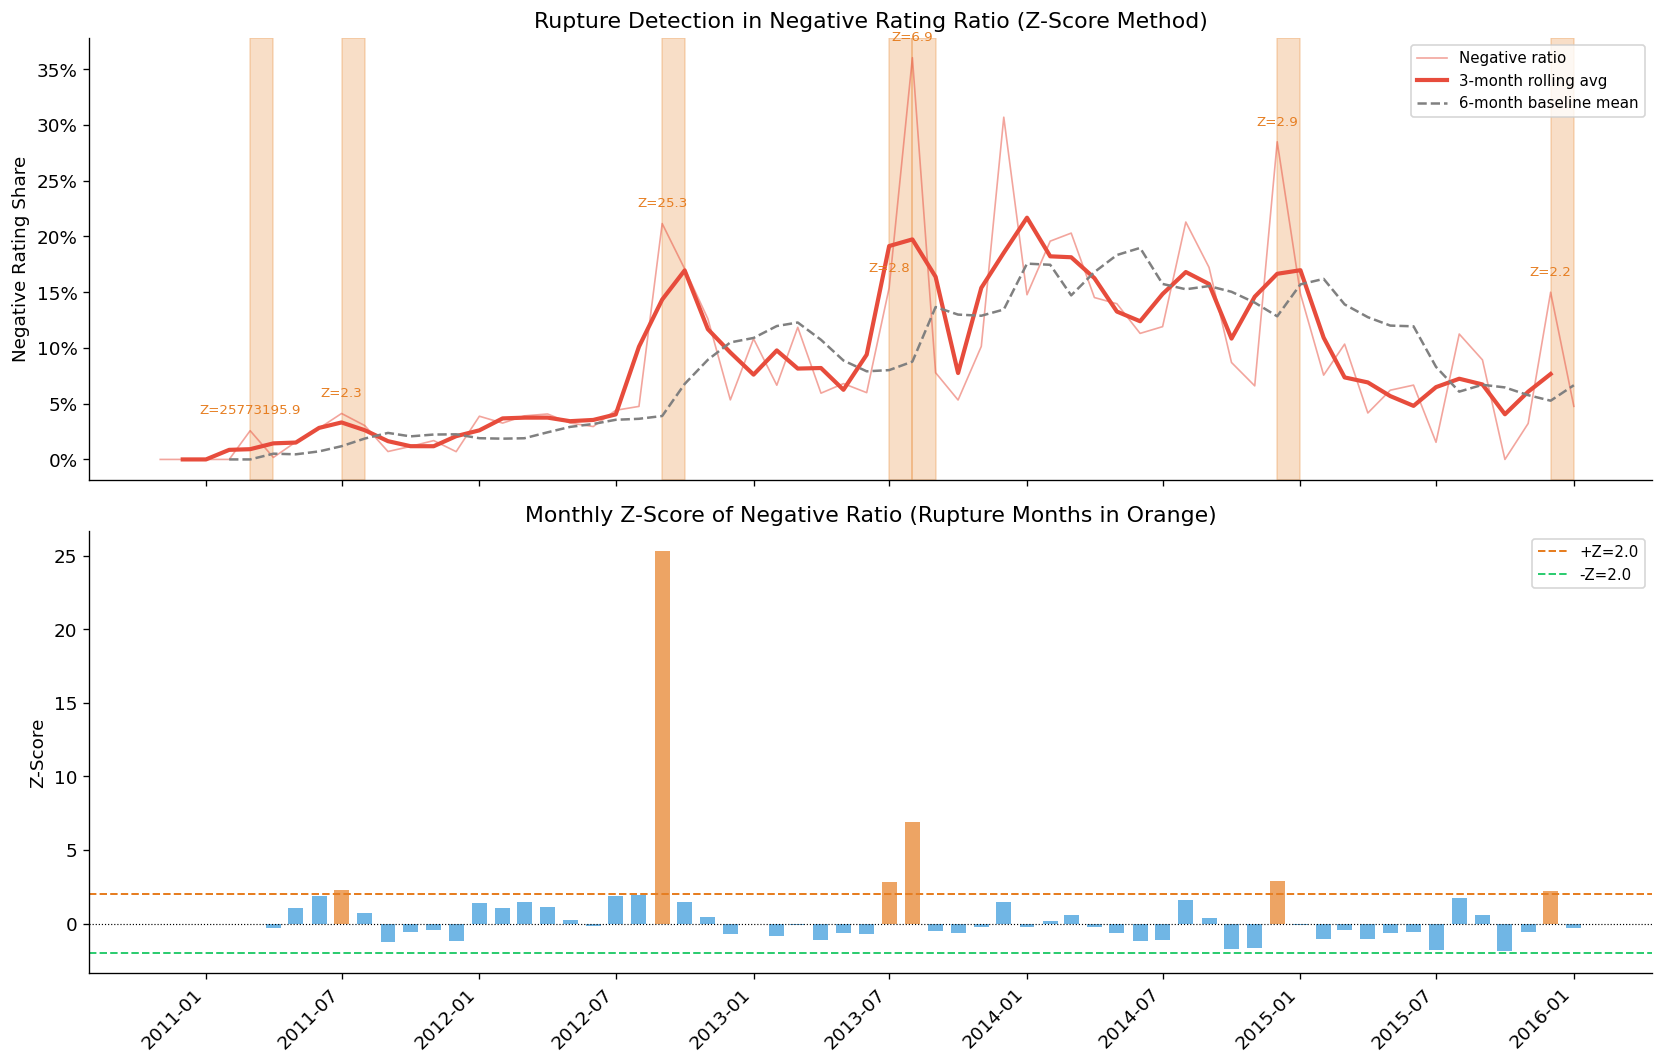

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1: Neg ratio + ruptures
ax = axes[0]
ax.plot(monthly['month_ts'], monthly['neg_ratio'], color=DISTRUST_COLOR, alpha=0.5, linewidth=1, label='Negative ratio')
ax.plot(monthly['month_ts'], monthly['neg_ratio_3m'], color=DISTRUST_COLOR, linewidth=2.5, label='3-month rolling avg')
ax.plot(monthly['month_ts'], monthly['roll_mean'], color='grey', linewidth=1.5, linestyle='--', label=f'{WINDOW}-month baseline mean')
# Highlight rupture months
for _, row in ruptures.iterrows():
    ax.axvspan(row['month_ts'], row['month_ts'] + pd.DateOffset(months=1),
               color=RUPTURE_COLOR, alpha=0.25, zorder=0)
    ax.annotate(f"Z={row['z_score']:.1f}",
                xy=(row['month_ts'], row['neg_ratio']),
                xytext=(0, 10), textcoords='offset points',
                fontsize=8, color=RUPTURE_COLOR, ha='center')
ax.set_ylabel('Negative Rating Share')
ax.set_title('Rupture Detection in Negative Rating Ratio (Z-Score Method)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=9)

# Panel 2: Z-score time series
ax = axes[1]
monthly_plot = monthly[monthly['z_score'].abs() < 200].copy()
ax.axhline(Z_THRESHOLD,  color=RUPTURE_COLOR, linestyle='--', linewidth=1.2, label=f'+Z={Z_THRESHOLD}')
ax.axhline(-Z_THRESHOLD, color=TRUST_COLOR,   linestyle='--', linewidth=1.2, label=f'-Z={Z_THRESHOLD}')
ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
ax.bar(monthly_plot['month_ts'], monthly_plot['z_score'],
       color=[RUPTURE_COLOR if v else NEUTRAL_COLOR for v in monthly_plot['is_rupture']],
       alpha=0.7, width=20)
ax.set_ylabel('Z-Score')
ax.set_title('Monthly Z-Score of Negative Ratio (Rupture Months in Orange)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rupture_detection.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Yearly Structural Metrics

We now build yearly snapshots of the network and compute key structural metrics for both the positive (trust) and negative (distrust) subgraphs:  

- Negative ratio — proportion of edges that are distrustful  
- Network density — how densely connected is each signed subgraph  
- Reciprocity — how often distrust/trust is reciprocated  
- Average clustering coefficient — local cohesion

Increasing density and reciprocity in the *negative* subgraph over time indicates structural polarization.

In [50]:
def compute_yearly_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Build yearly snapshots and compute signed-network structural metrics."""
    records = []

    # Cumulative snapshots (edges up to end of year)
    for year in sorted(df['year'].unique()):
        snap = df[df['year'] <= year]

        G      = nx.from_pandas_edgelist(snap, 'source', 'target', ['rating'], create_using=nx.DiGraph())
        G_pos  = nx.DiGraph([(u, v) for u, v, d in G.edges(data=True) if d['rating'] > 0])
        G_neg  = nx.DiGraph([(u, v) for u, v, d in G.edges(data=True) if d['rating'] < 0])

        N, L = G.number_of_nodes(), G.number_of_edges()
        L_neg = G_neg.number_of_edges()
        L_pos = G_pos.number_of_edges()

        rec_all = nx.reciprocity(G)     if L     > 0 else 0
        rec_neg = nx.reciprocity(G_neg) if L_neg > 0 else 0
        rec_pos = nx.reciprocity(G_pos) if L_pos > 0 else 0

        den_all = nx.density(G)
        den_neg = nx.density(G_neg) if G_neg.number_of_nodes() > 1 else 0
        den_pos = nx.density(G_pos) if G_pos.number_of_nodes() > 1 else 0

        # Avg clustering on largest WCC
        try:
            wcc_neg = max(nx.weakly_connected_components(G_neg), key=len)
            clust_neg = nx.average_clustering(G_neg.subgraph(wcc_neg).to_undirected())
        except (ValueError, ZeroDivisionError):
            clust_neg = 0

        try:
            wcc_pos = max(nx.weakly_connected_components(G_pos), key=len)
            clust_pos = nx.average_clustering(G_pos.subgraph(wcc_pos).to_undirected())
        except (ValueError, ZeroDivisionError):
            clust_pos = 0

        records.append(dict(
            year=year,
            n_nodes=N, n_edges=L,
            n_neg=L_neg, n_pos=L_pos,
            neg_ratio=L_neg/L if L > 0 else 0,
            density_all=den_all,  density_neg=den_neg,  density_pos=den_pos,
            reciprocity_all=rec_all, reciprocity_neg=rec_neg, reciprocity_pos=rec_pos,
            clustering_neg=clust_neg, clustering_pos=clust_pos,
            avg_rating=snap['rating'].mean(),
        ))

    return pd.DataFrame(records)

print("Computing yearly metrics (cumulative snapshots) — this may take ~30 s …")
yearly_metrics = compute_yearly_metrics(df)
print(yearly_metrics[['year','n_nodes','n_edges','neg_ratio','reciprocity_neg','density_neg','clustering_neg']].to_string(index=False))

Computing yearly metrics (cumulative snapshots) — this may take ~30 s …
 year  n_nodes  n_edges  neg_ratio  reciprocity_neg  density_neg  clustering_neg
 2010       55      142   0.000000         0.000000     0.000000        0.000000
 2011     1637     7900   0.019620         0.154839     0.007222        0.018539
 2012     3162    17332   0.055677         0.134715     0.002581        0.011509
 2013     5161    30314   0.092663         0.171591     0.001724        0.032837
 2014     5753    34539   0.100727         0.169014     0.001418        0.034556
 2015     5879    35550   0.100169         0.170739     0.001383        0.034142
 2016     5881    35592   0.100107         0.170643     0.001382        0.034118


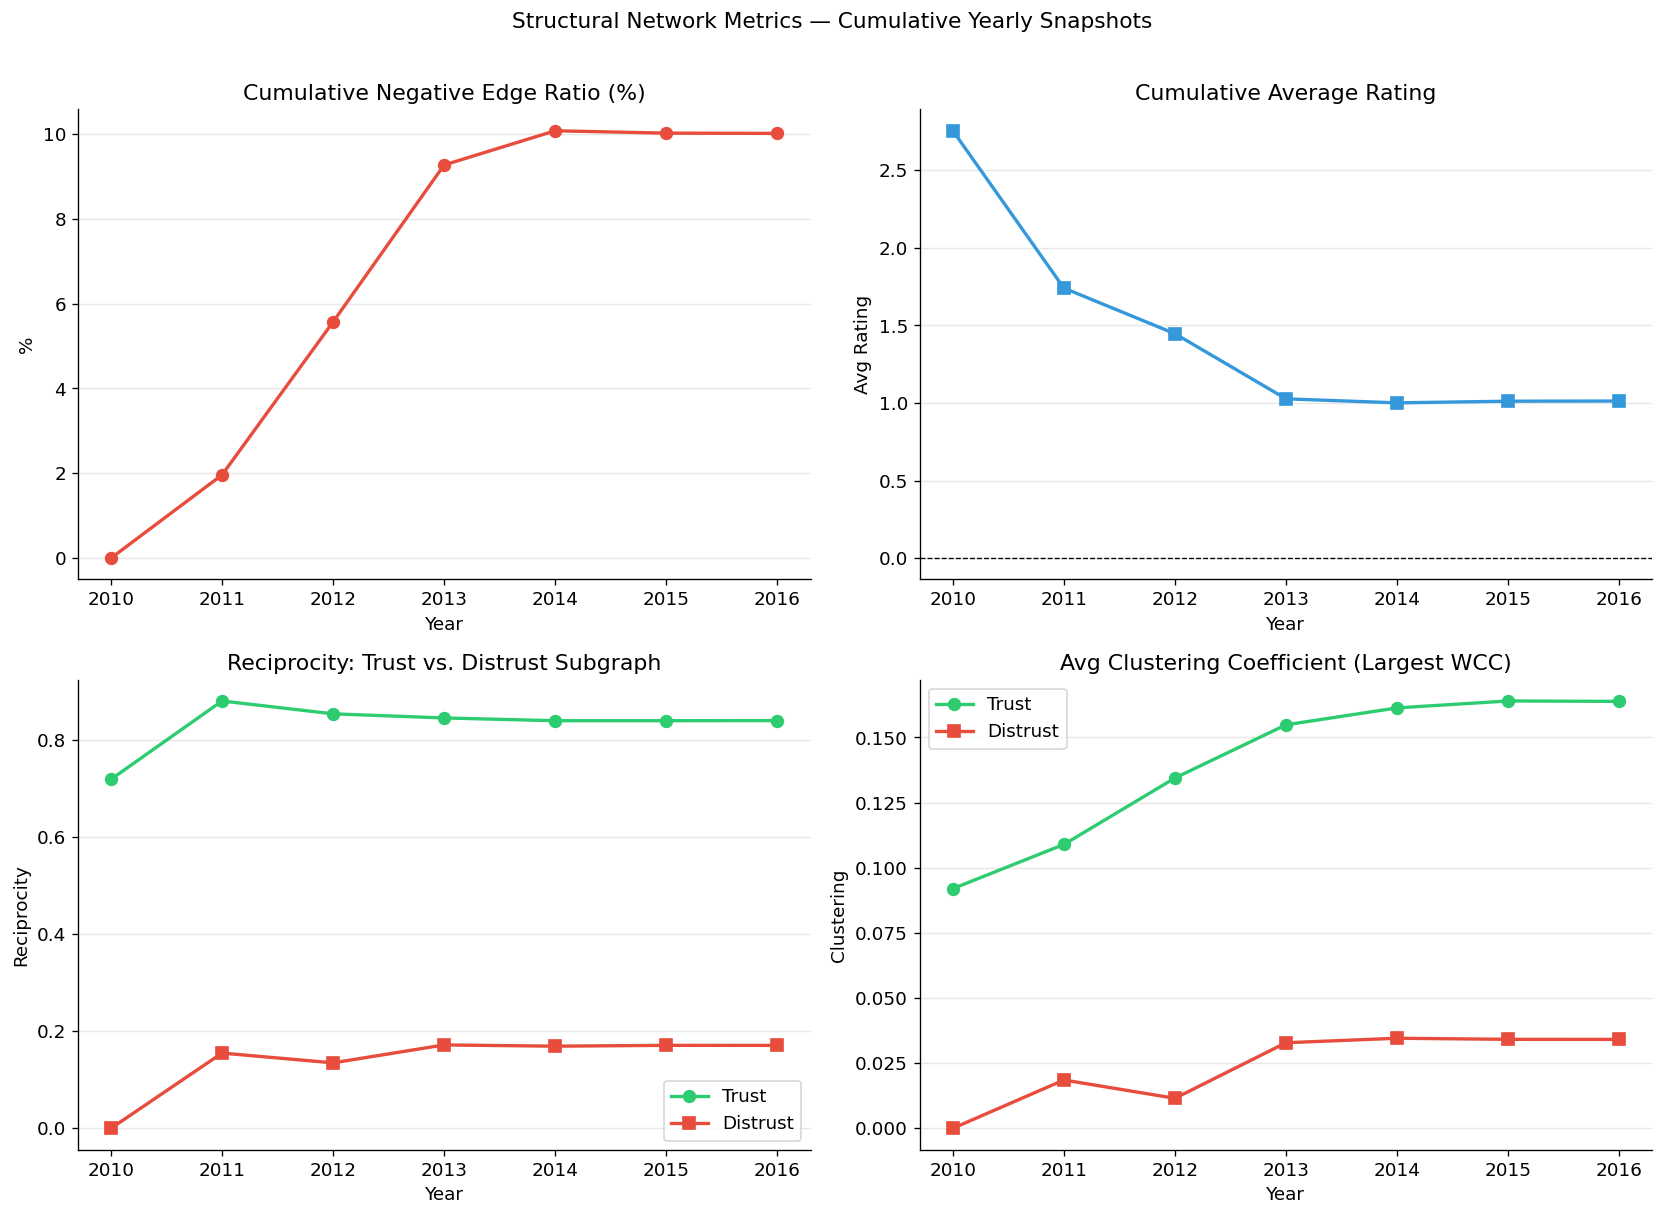

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
years = yearly_metrics['year'].values

# Negative ratio
ax = axes[0, 0]
ax.plot(years, yearly_metrics['neg_ratio'] * 100, 'o-', color=DISTRUST_COLOR, linewidth=2, markersize=7)
ax.set_title('Cumulative Negative Edge Ratio (%)'); ax.set_ylabel('%'); ax.set_xlabel('Year')
ax.set_xticks(years); ax.grid(axis='y', alpha=0.3)

# Average rating
ax = axes[0, 1]
ax.plot(years, yearly_metrics['avg_rating'], 's-', color=NEUTRAL_COLOR, linewidth=2, markersize=7)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Average Rating'); ax.set_ylabel('Avg Rating'); ax.set_xlabel('Year')
ax.set_xticks(years); ax.grid(axis='y', alpha=0.3)

# Reciprocity
ax = axes[1, 0]
ax.plot(years, yearly_metrics['reciprocity_pos'], 'o-', color=TRUST_COLOR,    linewidth=2, markersize=7, label='Trust')
ax.plot(years, yearly_metrics['reciprocity_neg'], 's-', color=DISTRUST_COLOR, linewidth=2, markersize=7, label='Distrust')
ax.set_title('Reciprocity: Trust vs. Distrust Subgraph')
ax.set_ylabel('Reciprocity'); ax.set_xlabel('Year')
ax.set_xticks(years); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Clustering
ax = axes[1, 1]
ax.plot(years, yearly_metrics['clustering_pos'], 'o-', color=TRUST_COLOR,    linewidth=2, markersize=7, label='Trust')
ax.plot(years, yearly_metrics['clustering_neg'], 's-', color=DISTRUST_COLOR, linewidth=2, markersize=7, label='Distrust')
ax.set_title('Avg Clustering Coefficient (Largest WCC)')
ax.set_ylabel('Clustering'); ax.set_xlabel('Year')
ax.set_xticks(years); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Structural Network Metrics — Cumulative Yearly Snapshots', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('yearly_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Distribution Shift of Ratings Over Time

Beyond aggregate proportions, we look at how the full rating distribution shifted across years.  
A distribution that migrates toward the extremes (±10) indicates that users are becoming more decisive — and potentially more hostile.

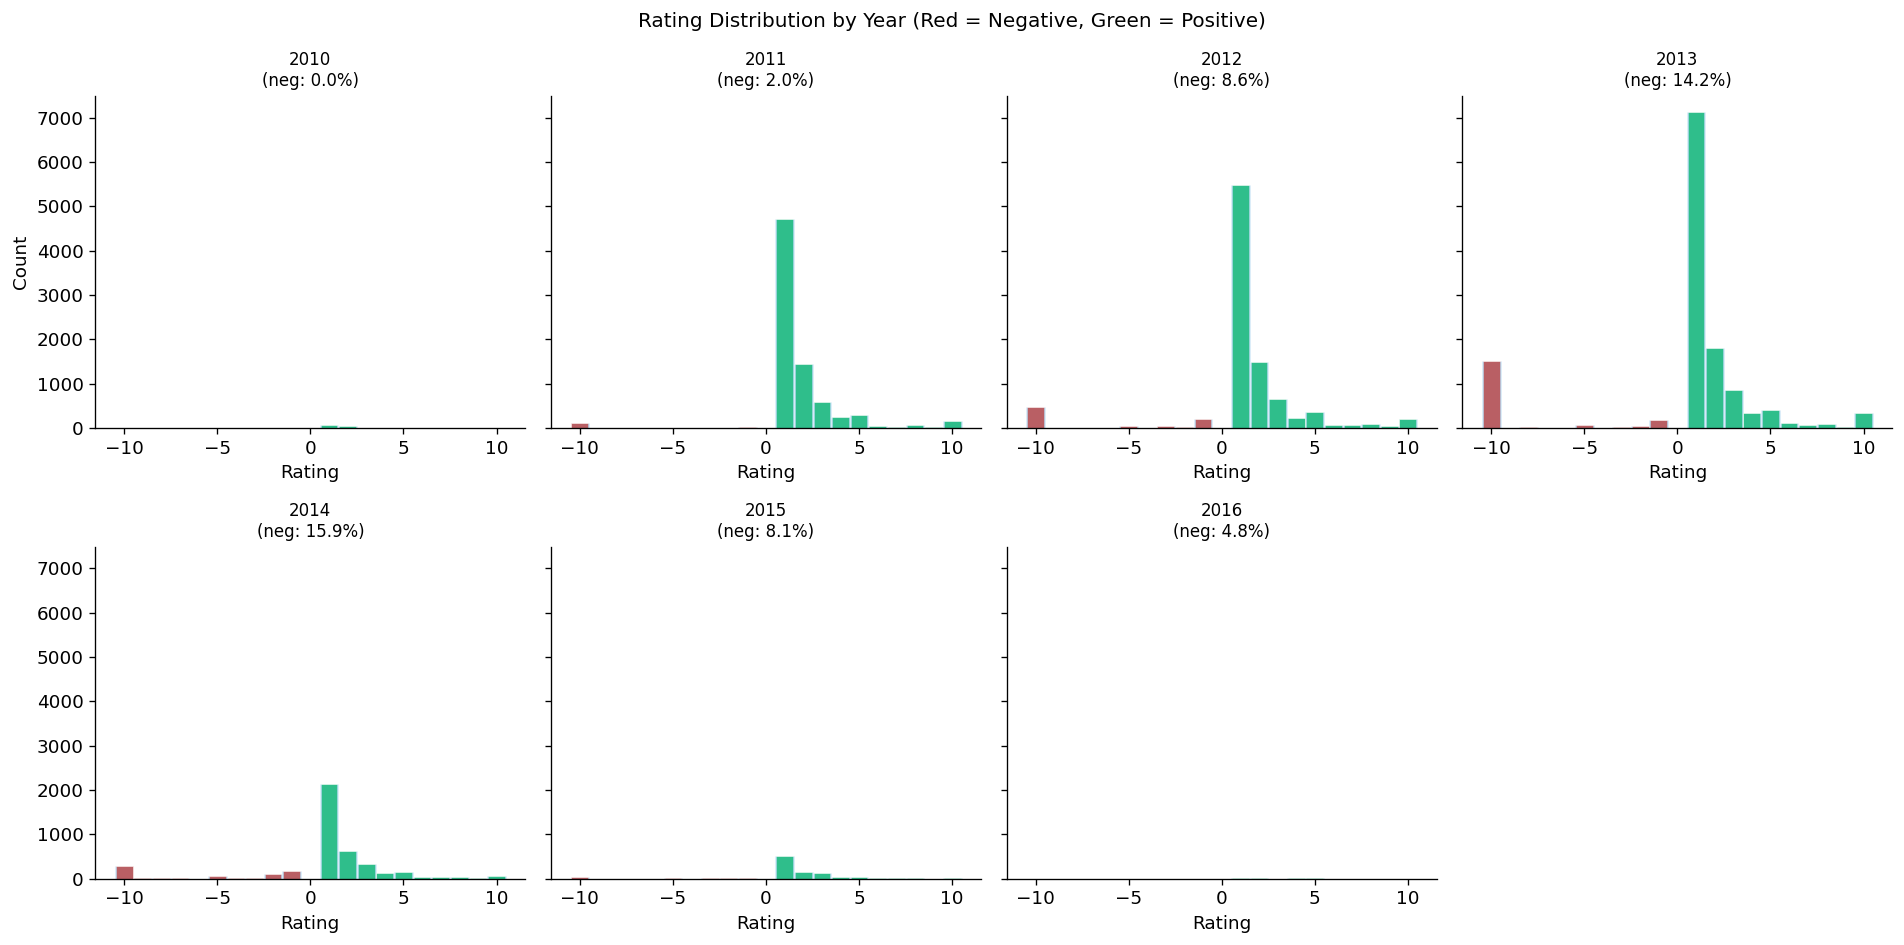

In [40]:
years_order = sorted(df['year'].unique())
n_years = len(years_order)

fig, axes = plt.subplots(2, (n_years + 1) // 2, figsize=(16, 8), sharey=True)
axes = axes.flatten()

BINS = np.arange(-10.5, 11, 1)

for i, yr in enumerate(years_order):
    subset = df[df['year'] == yr]['rating']
    neg_pct = (subset < 0).mean() * 100
    ax = axes[i]
    colors = [DISTRUST_COLOR if b < 0 else TRUST_COLOR for b in BINS[:-1] + 0.5]
    ax.hist(subset, bins=BINS, color=NEUTRAL_COLOR, edgecolor='white', linewidth=0.4)
    # Recolor negative bars
    counts, _ = np.histogram(subset, bins=BINS)
    for j, (count, b) in enumerate(zip(counts, BINS[:-1])):
        color = DISTRUST_COLOR if b + 0.5 < 0 else TRUST_COLOR
        axes[i].bar(b + 0.5, count, width=0.9, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{yr}\n(neg: {neg_pct:.1f}%)', fontsize=10)
    ax.set_xlabel('Rating')
    ax.set_xticks([-10, -5, 0, 5, 10])

axes[0].set_ylabel('Count')
# Hide extra axes if odd number of years
for j in range(n_years, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rating Distribution by Year (Red = Negative, Green = Positive)', fontsize=12)
plt.tight_layout()
plt.savefig('rating_distribution_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Heatmap — Monthly Negative Ratio Over the Full Period

A calendar-style heatmap offers an intuitive view of distrust intensity across the entire period, making it easy to spot both gradual trends and sudden spikes.

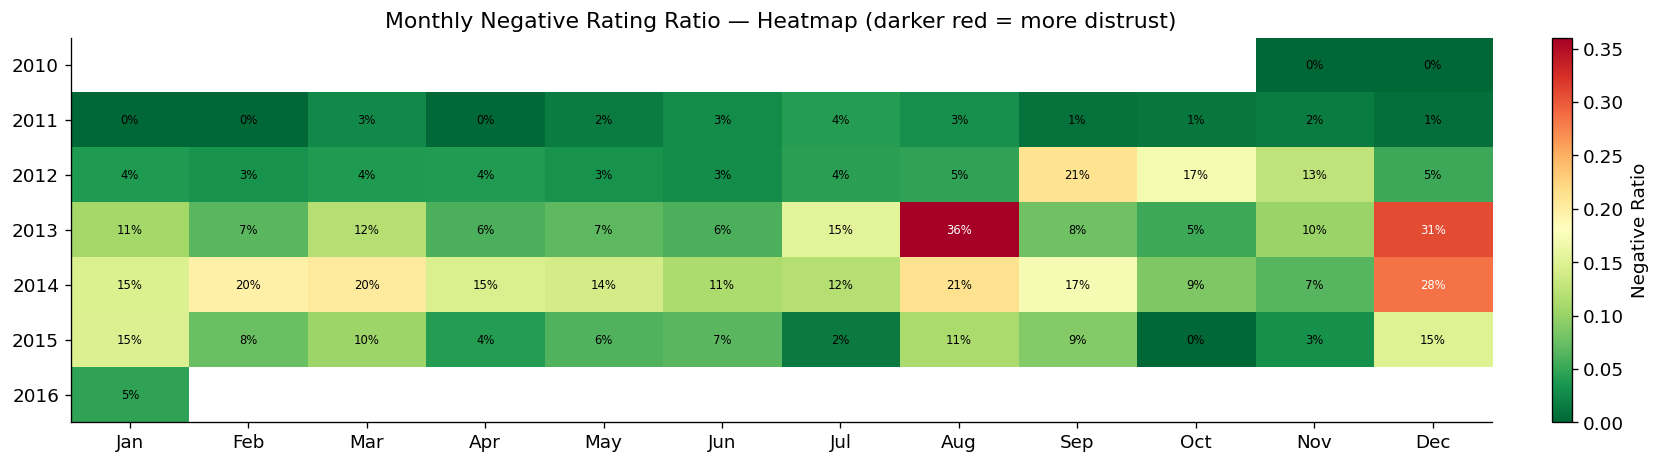

In [12]:
# Pivot: rows = year, cols = month number
monthly_full = (
    df.groupby(['year', df['timestamp'].dt.month])
    .agg(neg_ratio=('is_negative', 'mean'))
    .reset_index()
)
monthly_full.columns = ['year', 'month_num', 'neg_ratio']

pivot = monthly_full.pivot(index='year', columns='month_num', values='neg_ratio')

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=pivot.values[~np.isnan(pivot.values)].max())
ax.set_xticks(np.arange(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Monthly Negative Rating Ratio — Heatmap (darker red = more distrust)')

# Annotate cells with the value
for yr_i, yr in enumerate(pivot.index):
    for mo_i in range(12):
        val = pivot.values[yr_i, mo_i]
        if not np.isnan(val):
            ax.text(mo_i, yr_i, f'{val:.0%}', ha='center', va='center', fontsize=7,
                    color='white' if val > 0.25 else 'black')

plt.colorbar(im, ax=ax, label='Negative Ratio', fraction=0.02, pad=0.04)
plt.tight_layout()
plt.savefig('heatmap_neg_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. User Cohort Analysis — New vs. Established Users

We ask: do newly joined raters behave differently from established users?  
If negative ratings are disproportionately issued by newcomers, the polarization could be driven by network growth rather than a genuine shift in trust culture.

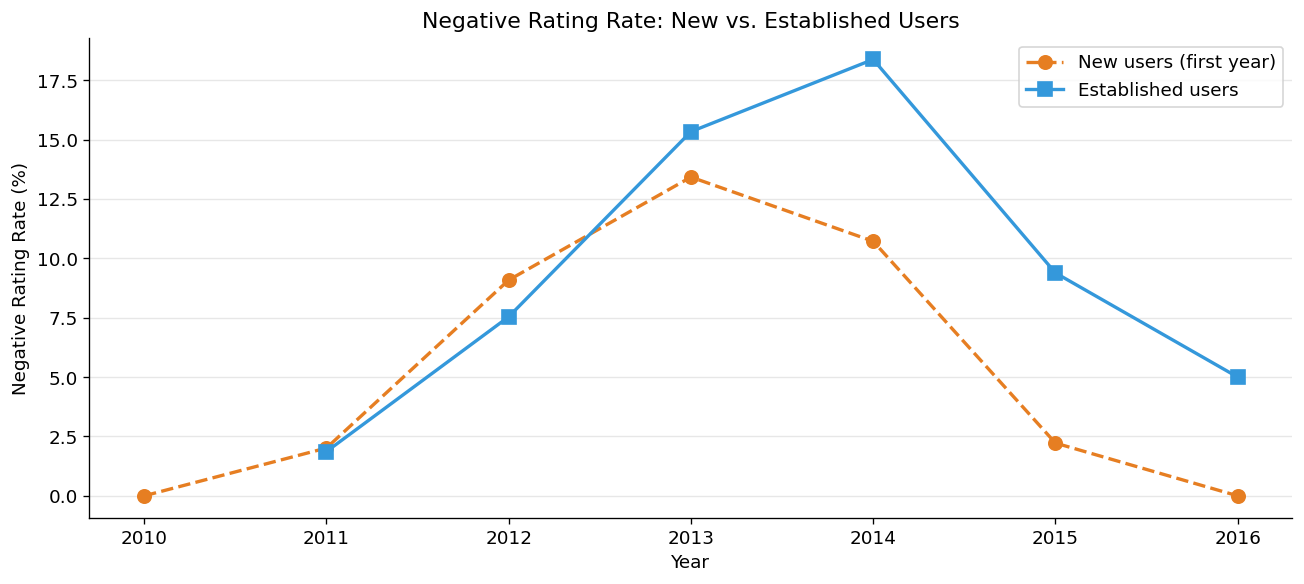

In [13]:
# First appearance year for each source node
first_seen = df.groupby('source')['year'].min().rename('cohort_year')
df_cohort = df.join(first_seen, on='source')
df_cohort['is_new'] = df_cohort['year'] == df_cohort['cohort_year']

cohort_stats = (
    df_cohort.groupby(['year', 'is_new'])
    .agg(
        neg_ratio=('is_negative', 'mean'),
        n=('rating', 'count')
    )
    .reset_index()
)

new_users  = cohort_stats[cohort_stats['is_new'] == True]
est_users  = cohort_stats[cohort_stats['is_new'] == False]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(new_users['year'], new_users['neg_ratio']*100, 'o--',
        color=RUPTURE_COLOR, linewidth=2, markersize=8, label='New users (first year)')
ax.plot(est_users['year'], est_users['neg_ratio']*100, 's-',
        color=NEUTRAL_COLOR, linewidth=2, markersize=8, label='Established users')
ax.set_xlabel('Year'); ax.set_ylabel('Negative Rating Rate (%)')
ax.set_title('Negative Rating Rate: New vs. Established Users')
ax.set_xticks(sorted(df['year'].unique()))
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Most Targeted Nodes During Rupture Periods

During the rupture months identified in Section 3, which nodes concentrated the most negative ratings? Consistent targeting of the same actors across ruptures suggests organized distrust campaigns rather than random noise.

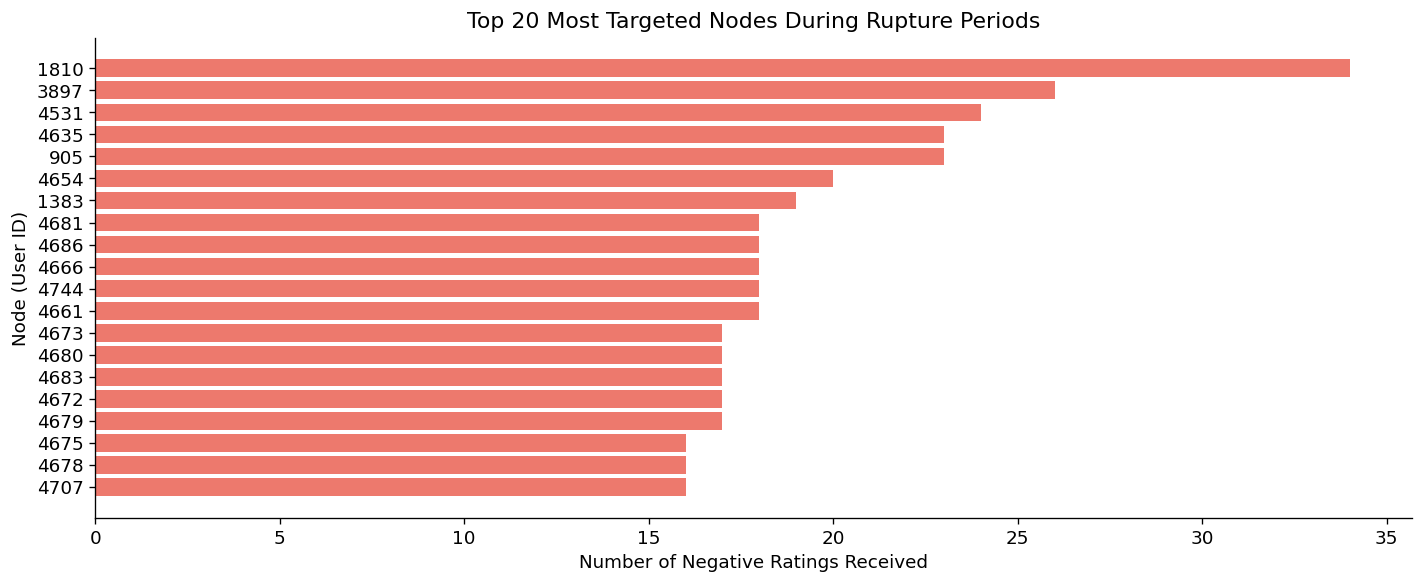

 target  neg_received  avg_neg_rating
   1810            34      -10.000000
   3897            26      -10.000000
   4531            24       -9.625000
   4635            23      -10.000000
    905            23       -9.478261
   4654            20      -10.000000
   1383            19       -8.105263
   4681            18      -10.000000
   4686            18      -10.000000
   4666            18      -10.000000
   4744            18      -10.000000
   4661            18      -10.000000
   4673            17      -10.000000
   4680            17      -10.000000
   4683            17      -10.000000
   4672            17      -10.000000
   4679            17      -10.000000
   4675            16      -10.000000
   4678            16      -10.000000
   4707            16      -10.000000


In [14]:
if len(ruptures) > 0:
    rupture_months = set(ruptures['month'].astype(str))
    df_rup = df[df['month'].astype(str).isin(rupture_months) & df['is_negative']]

    top_targets = (
        df_rup.groupby('target')
        .agg(neg_received=('rating', 'count'), avg_neg_rating=('rating', 'mean'))
        .sort_values('neg_received', ascending=False)
        .head(20)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(top_targets['target'].astype(str), top_targets['neg_received'],
                   color=DISTRUST_COLOR, alpha=0.75)
    ax.set_xlabel('Number of Negative Ratings Received')
    ax.set_ylabel('Node (User ID)')
    ax.set_title('Top 20 Most Targeted Nodes During Rupture Periods')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('top_targeted_nodes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(top_targets.to_string(index=False))
else:
    print("No rupture periods detected with current threshold.")

## 9. Quarterly Polarization Index

We define a simple Polarization Index (PI) as:

$$PI = \frac{|E^-|}{|E^+ + E^-|}$$

where $E^+$ and $E^-$ are the numbers of positive and negative edges in a given period.  
We supplement this with the average absolute deviation of ratings from the neutral midpoint (0), which captures whether users are giving increasingly extreme scores.

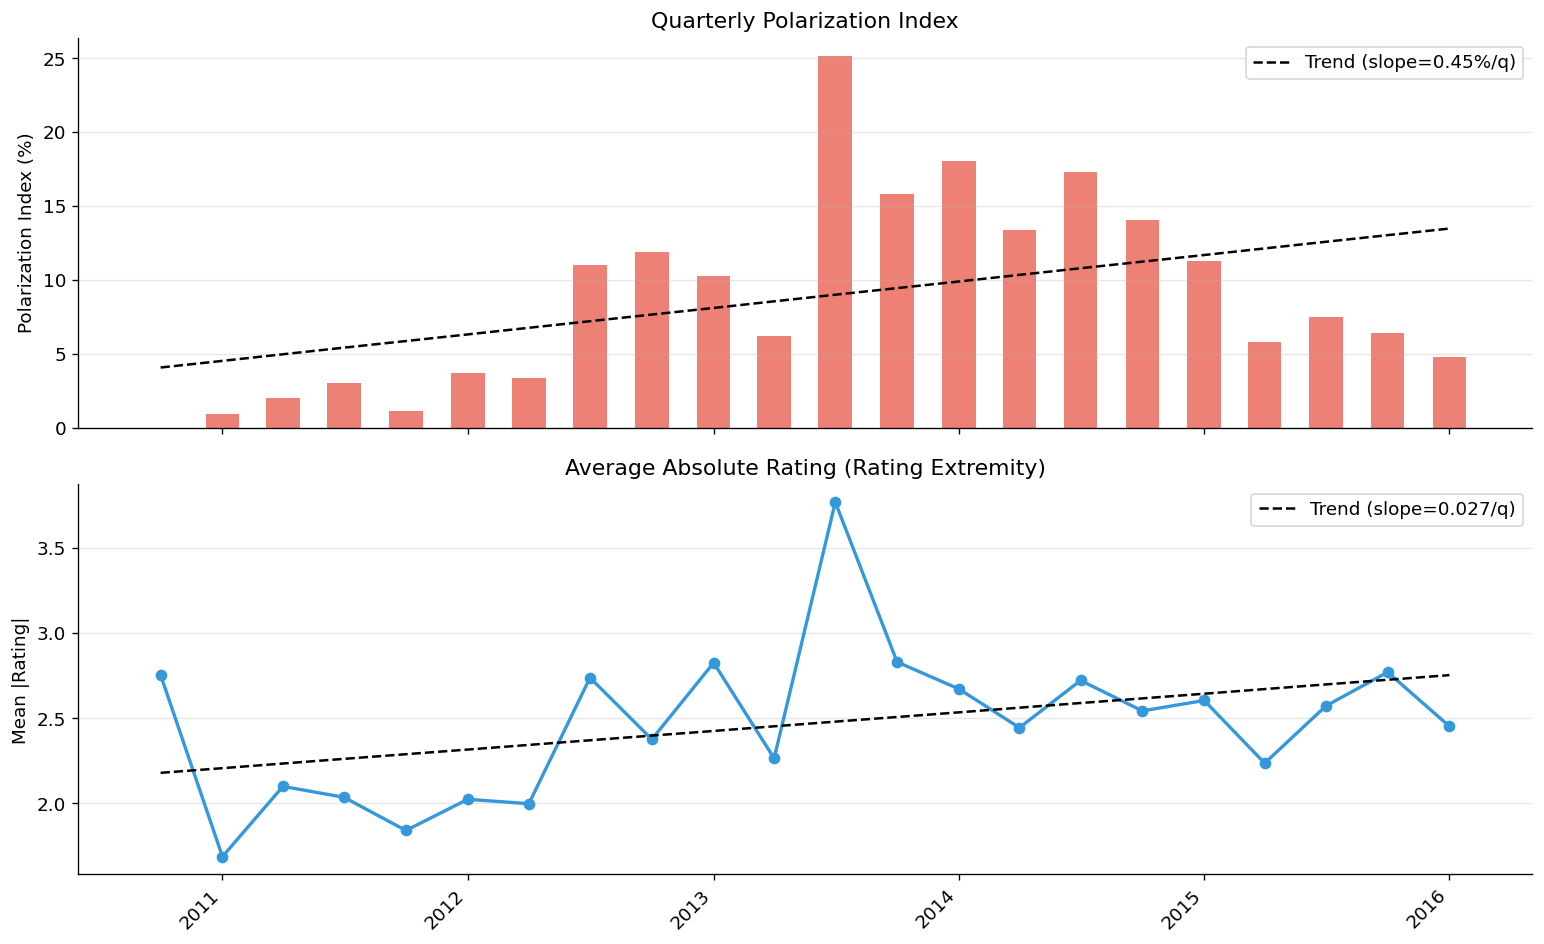

In [15]:
quarterly_stats = (
    df.groupby('quarter')
    .agg(
        total=('rating', 'count'),
        negative=('is_negative', 'sum'),
        positive=('is_positive', 'sum'),
        avg_abs_rating=('rating', lambda x: x.abs().mean()),
        avg_rating=('rating', 'mean'),
    )
    .reset_index()
)
quarterly_stats['PI'] = quarterly_stats['negative'] / (
    quarterly_stats['positive'] + quarterly_stats['negative'] + 1e-9
)
quarterly_stats['quarter_ts'] = quarterly_stats['quarter'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.bar(quarterly_stats['quarter_ts'], quarterly_stats['PI']*100,
       color=DISTRUST_COLOR, alpha=0.7, width=50)
z = np.polyfit(
    range(len(quarterly_stats)),
    quarterly_stats['PI']*100, 1
)
trend = np.poly1d(z)(range(len(quarterly_stats)))
ax.plot(quarterly_stats['quarter_ts'], trend, 'k--', linewidth=1.5, label=f'Trend (slope={z[0]:.2f}%/q)')
ax.set_ylabel('Polarization Index (%)')
ax.set_title('Quarterly Polarization Index')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(quarterly_stats['quarter_ts'], quarterly_stats['avg_abs_rating'],
        'o-', color=NEUTRAL_COLOR, linewidth=2, markersize=6)
z2 = np.polyfit(range(len(quarterly_stats)), quarterly_stats['avg_abs_rating'], 1)
trend2 = np.poly1d(z2)(range(len(quarterly_stats)))
ax.plot(quarterly_stats['quarter_ts'], trend2, 'k--', linewidth=1.5,
        label=f'Trend (slope={z2[0]:.3f}/q)')
ax.set_ylabel('Mean |Rating|')
ax.set_title('Average Absolute Rating (Rating Extremity)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-Q%q' if hasattr(mdates, 'QuarterLocator') else '%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('polarization_index.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary and Conclusions

This cell prints a structured summary of all findings to help answer the research question.

In [16]:
# Summary statistics
early = df[df['year'] <= 2011]
late  = df[df['year'] >= 2014]

early_neg_rate = early['is_negative'].mean() * 100
late_neg_rate  = late['is_negative'].mean()  * 100

early_avg = early['rating'].mean()
late_avg  = late['rating'].mean()

early_y = yearly_metrics[yearly_metrics['year'] <= 2011]['clustering_neg'].mean()
late_y  = yearly_metrics[yearly_metrics['year'] >= 2014]['clustering_neg'].mean()

n_ruptures = len(ruptures)

print("="*65)
print("  SUMMARY — Bitcoin-OTC Trust Polarization Analysis")
print("="*65)
print()
print(f"  Dataset period : 2010 – 2016  ({len(df):,} edges)")
print()
print("  1. HAS DISTRUST GROWN?")
print(f"     Early period (≤2011)  neg rate : {early_neg_rate:.1f}%")
print(f"     Late  period (≥2014)  neg rate : {late_neg_rate:.1f}%")
direction = "INCREASED" if late_neg_rate > early_neg_rate else "DECREASED"
print(f"     → Negative rating share has {direction} over time.")
print()
print("  2. HAS AVERAGE RATING DECLINED?")
print(f"     Early avg rating : {early_avg:.3f}")
print(f"     Late  avg rating : {late_avg:.3f}")
direction2 = "DECLINED" if late_avg < early_avg else "IMPROVED"
print(f"     → Average trust score has {direction2} over time.")
print()
print("  3. STRUCTURAL POLARIZATION")
print(f"     Avg clustering (distrust subgraph) early : {early_y:.4f}")
print(f"     Avg clustering (distrust subgraph) late  : {late_y:.4f}")
direction3 = "GROWN" if late_y > early_y else "DECLINED"
print(f"     → Distrust sub-network cohesion has {direction3}.")
print()
print("  4. RUPTURE PERIODS")
print(f"     Number of anomalous months detected : {n_ruptures}")
if n_ruptures > 0:
    for _, row in ruptures.iterrows():
        print(f"       • {row['month']}  |  neg ratio = {row['neg_ratio']:.1%}  |  Z = {row['z_score']:.2f}")
print()
print("  CONCLUSION")
overall = (
    (late_neg_rate > early_neg_rate) +
    (late_avg < early_avg) +
    (late_y > early_y) +
    (n_ruptures > 0)
)
if overall >= 3:
    print("  Strong evidence that the Bitcoin-OTC network became")
    print("  MORE POLARIZED AND DISTRUSTFUL over time, with identifiable")
    print("  rupture periods suggesting collective shifts in trust behavior.")
elif overall >= 2:
    print("  Moderate evidence of growing polarization and distrust,")
    print("  with some rupture periods identified.")
else:
    print("  Limited evidence of systematic polarization growth.")
print("="*65)

  SUMMARY — Bitcoin-OTC Trust Polarization Analysis

  Dataset period : 2010 – 2016  (35,592 edges)

  1. HAS DISTRUST GROWN?
     Early period (≤2011)  neg rate : 2.0%
     Late  period (≥2014)  neg rate : 14.3%
     → Negative rating share has INCREASED over time.

  2. HAS AVERAGE RATING DECLINED?
     Early avg rating : 1.740
     Late  avg rating : 0.930
     → Average trust score has DECLINED over time.

  3. STRUCTURAL POLARIZATION
     Avg clustering (distrust subgraph) early : 0.0093
     Avg clustering (distrust subgraph) late  : 0.0343
     → Distrust sub-network cohesion has GROWN.

  4. RUPTURE PERIODS
     Number of anomalous months detected : 7
       • 2011-03  |  neg ratio = 2.6%  |  Z = 25773195.88
       • 2011-07  |  neg ratio = 4.1%  |  Z = 2.25
       • 2012-09  |  neg ratio = 21.2%  |  Z = 25.29
       • 2013-07  |  neg ratio = 15.4%  |  Z = 2.82
       • 2013-08  |  neg ratio = 36.0%  |  Z = 6.93
       • 2014-12  |  neg ratio = 28.5%  |  Z = 2.86
       • 2015-